<a href="https://colab.research.google.com/github/vitorjensen/Python_para_Dados/blob/main/Projetos/An%C3%A1lise%20Explorat%C3%B3ria%20de%20Danos%20Informados/An%C3%A1lise_Explorat%C3%B3ria_de_Danos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### Importando bibliotecas.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

##### **Objetivo:** Fazer uma análise exploratória de Danos em todos os estados por todo período de 2024.

##### Os dados de Danos são todas as ocorrências de desastres e eventos de calamidades acontecidas nas regiões do Brasil e que envolveram mortes ou feridos.



##### Importando a base de dados para análise.

In [6]:
df = pd.read_csv("/content/drive/MyDrive/Danos_Informados.csv");

##### **Primeira parte da Análise Exploratória:**
Tratemento:
  - Remover colunas não utilizadas
  - Trocar os valores "0" por "Null"
  - Total de Nulos e Duplicados
  - Total de colunas e linhas

In [ ]:
# Visualizando o DataFrame
df.head()

In [ ]:
# Removendo colunas indesejadas
df.columns

index_coluna_dh_outros_afetados = df.columns.get_loc("DH_Outros Afetados") #Pegando a localização da coluna "DH_Outros Afetados"
colunas_para_deletar = df.columns[index_coluna_dh_outros_afetados + 1:] #Definindo o espaço de colunas a serem deletadas após.
df = df.drop(columns=colunas_para_deletar) # Comando Drop para deletar.
display(df.head())

In [ ]:
# Trocando os valores de 0 por Null
df.replace(0, np.nan, inplace=True)
display(df)

In [10]:
# Realizando novo download da base de dados
df.to_csv('Danos_Informados_atualizado.csv', index=False)
print('DataFrame salvo como Danos_Informados_atualizado.csv')

DataFrame salvo como Danos_Informados_atualizado.csv


In [11]:
# Somando os valores nulos.
valores_nulos = df.isnull().sum().sum()
print(f"Temos um total de: {valores_nulos} valores nulos.")

Temos um total de: 36459 valores nulos.


In [12]:
# Identificando valores duplicados
duplicados = df.duplicated().sum()
print(f"Temos ao todo: {duplicados} registros duplicados")

Temos ao todo: 0 registros duplicados


In [ ]:
df.info()

##### **Resumo do tratamento:**
  - Total de linhas da tabela: 6032
  - Total de colunas após a limpeza: 53 -> 14
  - Total de valores nulos na tabela: 36459
  - Total de valores duplicados: 0

##### **Iniciando segunda parte da Análise Exploratória:**
Definir:
  - Total de categorias distintas de Desastres.
  - Colunas Categóricas e sua Análise Univariada.
  - Colunas Númericas e sua Análise Univariada.
  - Correlação Linear
  - A Importância das colunas "DH".

In [ ]:
# Listando todas as categorias distintas de desastres
print(f"Categorias de desastres", end=" ")
print(df['COBRADE'].unique())

In [15]:
# Somando o total de categorias distintas de desastres
print(f"Categorias de desastres", end=" ")
print(df['COBRADE'].nunique())

Categorias de desastres 49


In [16]:
# Verificando colunas categóricas
colunas_categoricas = [coluna for coluna in df.columns
                       if df[coluna].dtype == 'object']


# Verificando colunas numéricas:
colunas_numericas = [coluna for coluna in df.columns
                     if df[coluna].dtype != 'object']
print(f"Temos um total de {len(colunas_categoricas)} colunas categóricas.")
print(f"Temos um total de {len(colunas_numericas)} colunas numéricas.")

Temos um total de 6 colunas categóricas.
Temos um total de 8 colunas numéricas.


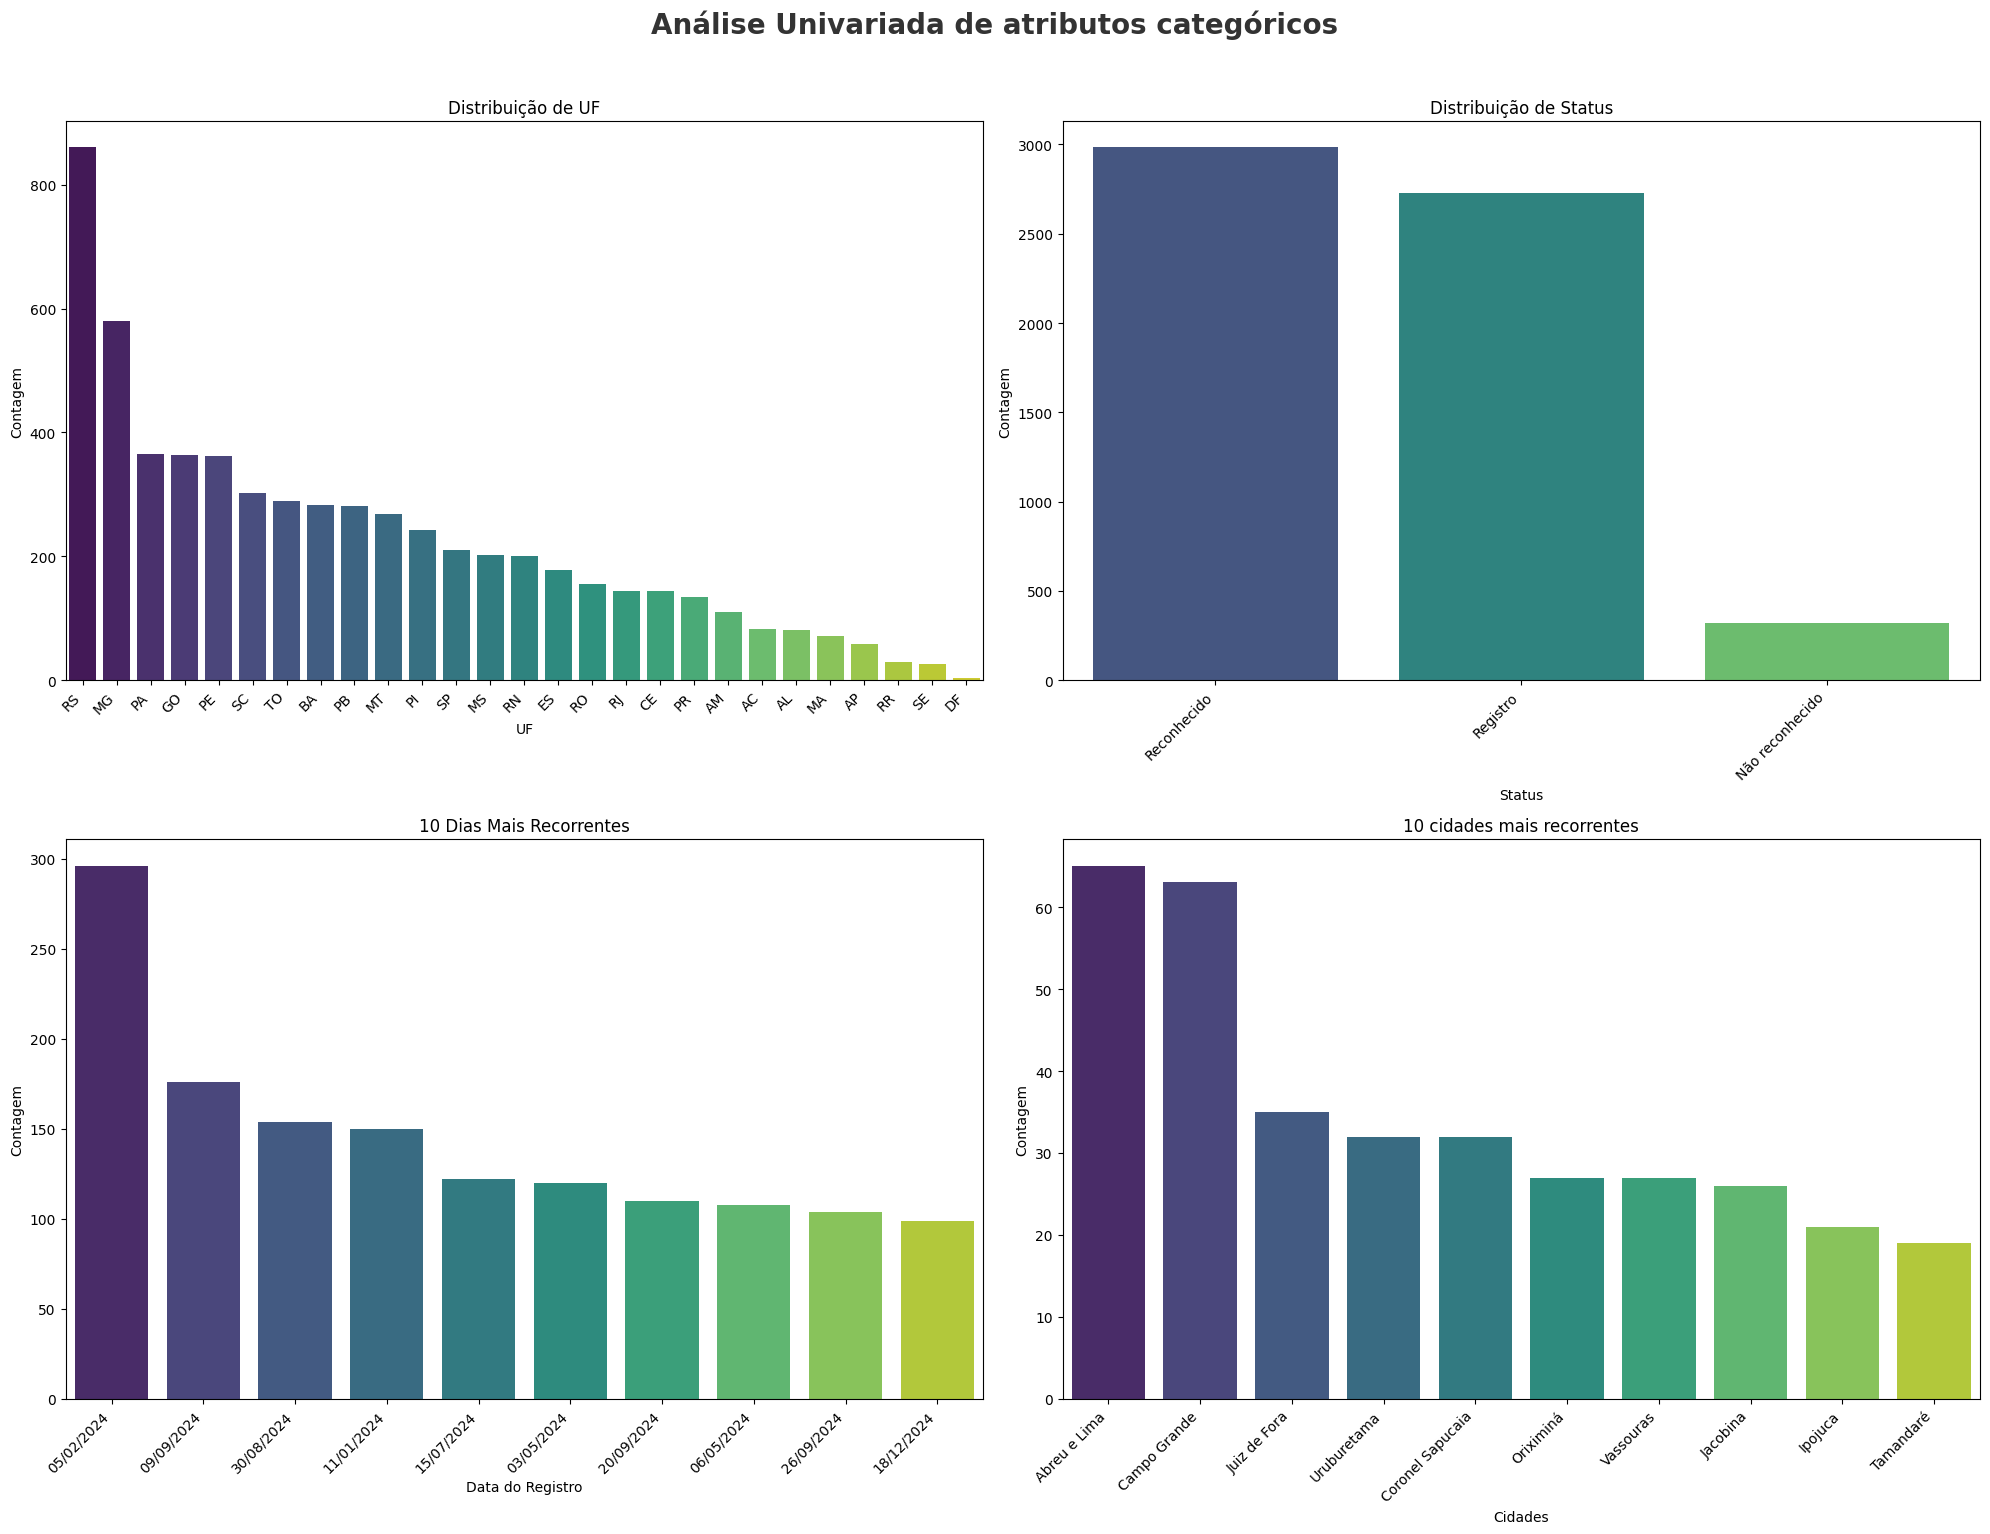

In [17]:
# Análise Univariada dos Atributos Categóricos.

warnings.filterwarnings('ignore')

dias_mais_recorrentes = df['Registro'].value_counts().head(10) # Fazendo uma contagem das 10 datas mais recorrentes.
cidades_mais_recorrentes = df['Município'].value_counts().head(10) # Fazendo um contagem das 10 cidades mais recorrentes.

# Definindo as colunas categóricas para plotar
atributos_categoricos = ['UF', 'Status']

# Criando a figura
plt.figure(figsize=(20, 15))
plt.suptitle("Análise Univariada de atributos categóricos", fontsize=20, fontweight='bold', alpha=0.8, y=1.02)

# Criando os subplots das colunas categóricas

for i, categoria in enumerate(atributos_categoricos): #Usando a função enumerate, para extrair um par de informações: índice(i) e posição(categoria).
  plt.subplot(2, 2, i + 1) # Formatando a visualização em 2 linhas, 2 colunas e falando para i assumir a posição inicial (0) e somar 1 para acessar cada item da lista (atributos_categoricos).
  sns.countplot(x=df[categoria], order=df[categoria].value_counts().index, palette='viridis') #Definindo o eixo X, como será a ordem dos itens dados em "categoria" e uma paleta de cores
  plt.title(f'Distribuição de {categoria}') # Defini um título para cada gráfico
  plt.xlabel(categoria) #Coloca o texto dos índices dispostos no eixo X do gráfico
  plt.ylabel('Contagem') # Defini um texto padrão para o eixo Y
  plt.xticks(rotation=45, ha='right') # definindo a rotação dos textos no eixo X e o tipo de alinhamento horizontal (ha=right)
  plt.tight_layout() # Ajusta o layout para evitar sobreposição, deixando espaço para o suptitle

# Plotando as 10 datas mais recorrentes

plt.subplot(2, 2, len(atributos_categoricos) + 1) # Adiciona o quarto subplot, tamanho da variável + 1
sns.barplot(x=dias_mais_recorrentes.index, y=dias_mais_recorrentes.values, palette='viridis')
plt.title('10 Dias Mais Recorrentes')
plt.xlabel('Data do Registro')
plt.ylabel('Contagem')
plt.xticks(rotation=45, ha='right') # definindo a rotação dos textos no eixo X e o tipo de alinhamento horizontal (ha=right)
plt.tight_layout() # Ajusta o layout para evitar sobreposição, deixando espaço para o suptitle

# Plotando as 10 cidades mais recorrentes
plt.subplot(2, 2, len(atributos_categoricos) + 2)
sns.barplot(x=cidades_mais_recorrentes.index, y=cidades_mais_recorrentes.values, palette='viridis')
plt.title('10 cidades mais recorrentes')
plt.xlabel('Cidades')
plt.ylabel('Contagem')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

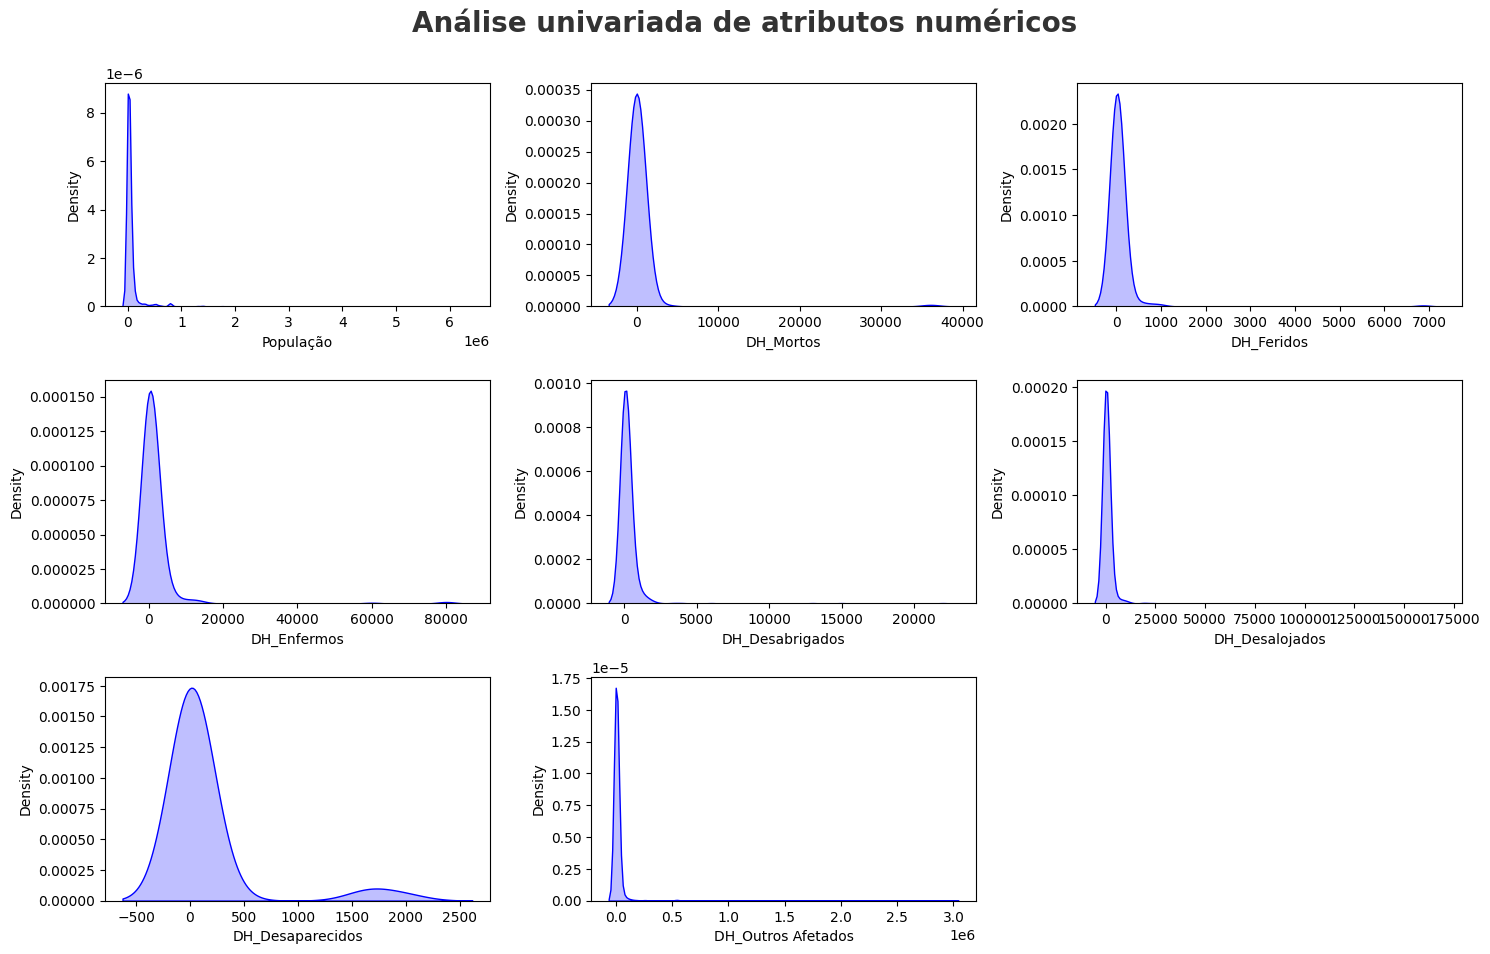

In [18]:
# Análise Univariada de Atributos Numéricos:

# Criando a figura principal
plt.figure(figsize=(15,15))
plt.suptitle("Análise univariada de atributos numéricos", fontsize=20, fontweight='bold',alpha=0.8, y=1)

for i in range(len(colunas_numericas)):
  plt.subplot(5,3,i+1)
  sns.kdeplot(x=df[colunas_numericas[i]],shade=True,color='b')
  plt.xlabel(colunas_numericas[i])
  plt.tight_layout()



In [19]:
# Correlação Linear
df[colunas_numericas].corr()

,População,DH_Mortos,DH_Feridos,DH_Enfermos,DH_Desabrigados,DH_Desalojados,DH_Desaparecidos,DH_Outros Afetados
População,1.000000,-0.018894,-0.010314,0.070732,0.037232,0.055406,-0.062253,0.581325
DH_Mortos,-0.018894,1.000000,-0.105667,0.737332,-0.045830,-0.028059,-0.090464,-0.043025
DH_Feridos,-0.010314,-0.105667,1.000000,0.175028,0.535158,0.276072,0.514370,-0.060262
DH_Enfermos,0.070732,0.737332,0.175028,1.000000,-0.006373,0.082031,-0.039789,0.263669
DH_Desabrigados,0.037232,-0.045830,0.535158,-0.006373,1.000000,0.901290,0.511693,0.071261
DH_Desalojados,0.055406,-0.028059,0.276072,0.082031,0.901290,1.000000,-0.003042,0.077392
DH_Desaparecidos,-0.062253,-0.090464,0.514370,-0.039789,0.511693,-0.003042,1.000000,-0.073354
DH_Outros Afetados,0.581325,-0.043025,-0.060262,0.263669,0.071261,0.077392,-0.073354,1.000000


##### **Resumo da segunda parte da Análise Exploratória:**
- Categorias distintas de desastres: 49
- Colunas Categóricas: 8
- Colunas Numéricas: 6
- As colunas "DH's" (Danos Humanos) são importantes para que se possa entender a gravidade de um desastre para então classifica-lo ou a vulnerabilidade de um local.